In [501]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Visualizacion de datos.

In [502]:
df = pd.read_csv("../data/raw/farmacia-datos.csv", sep=";", encoding="latin1")
df.head()

,Fecha,Tipo Mov.,Fac. Tipo,Fac. Suc.,Fac. Nun.,Fisc. Numero,Tipo Pago,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Ajustes,Desc. Adic.,Total. Cliente,IVA,Tasa Iva,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,0,379923,NaN,E,1,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,0,9344,0,0,0,9344
1,01/01/25 01.59.21,F,B,0,379924,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,0,"5142,11",0,0,0,"8174,96"
2,01/01/25 02.01.59,F,B,0,379925,NaN,E,1,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,0,"2856,86",0,0,0,"8174,96"
3,01/01/25 02.04.14,F,B,0,379926,NaN,E,1,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,0,"8086,82",0,0,0,"8086,82"
4,01/01/25 02.08.35,F,B,0,379927,NaN,E,1,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,0,"26750,12",0,0,0,"26750,12"


In [503]:
df.shape

(117415, 20)

In [504]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117415 entries, 0 to 117414
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             117415 non-null  object 
 1   Tipo Mov.         117415 non-null  object 
 2   Fac. Tipo         117415 non-null  object 
 3   Fac. Suc.         117415 non-null  int64  
 4   Fac. Nun.         117415 non-null  int64  
 5   Fisc. Numero      0 non-null       float64
 6   Tipo Pago         117415 non-null  object 
 7   Cant.             117415 non-null  int64  
 8   Precio            117415 non-null  object 
 9   Producto          117414 non-null  object 
 10  Sub. Total        117415 non-null  object 
 11  Rubro             117415 non-null  object 
 12  Cobertura         117415 non-null  object 
 13  Ajustes           117415 non-null  int64  
 14  Desc. Adic.       117415 non-null  object 
 15  Total. Cliente    117415 non-null  object 
 16  IVA               11

In [505]:
df.duplicated().sum()

np.int64(121)

In [506]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df.duplicated().sum()

np.int64(0)

### Observaciones
>
>Logramo visualizar los datos. En  cada linea podemos entender que es una compra. algunas comparten el mismo numero de ticket lo que nos da a entender que cada linea es un articulo que se compro, algunas variables categoricas parecen ser numericas, las estudiaremos para modificarlas si se necesita. Encontramos unos duplicados pero para descartarlas tomamos la decision de evaluarlas antes para tener una decision mas acertada. Tenemos 20 columnas y estudiaremos cada una de ellas.
>
>En el analisis inicial notamos tambien que la fila `Fisc. Numero` no tiene ningun valor en ninguna columna. asi que procederemos a borrar directamente esa columna.
>Tambien 

In [507]:
df.drop(["Fisc. Numero"],
              axis=1, inplace=True)

## Analisis de variables.

### Analisis de variables categoricas

>Empezaremos evaluando las variables categoricas para evaluar que contiene cada una de ellas.

In [508]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fecha',
 'Tipo Mov.',
 'Fac. Tipo',
 'Tipo Pago',
 'Precio',
 'Producto',
 'Sub. Total',
 'Rubro',
 'Cobertura',
 'Desc. Adic.',
 'Total. Cliente',
 'IVA',
 'Total Gravado',
 'Total sin Gravar']

In [509]:
df[cat_variables].head()

,Fecha,Tipo Mov.,Fac. Tipo,Tipo Pago,Precio,Producto,Sub. Total,Rubro,Cobertura,Desc. Adic.,Total. Cliente,IVA,Total Gravado,Total sin Gravar
0,01/01/25 01.13.46,F,B,E,9344,ACTRON PEDIATRICO 4% susp.oral x 100 ml,9344,FARMACIA,0,0,9344,0,0,9344
1,01/01/25 01.59.21,F,B,E,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"3032,85",0,"5142,11",0,0,"8174,96"
2,01/01/25 02.01.59,F,B,E,"8174,96",AMOXIDAL 500 mg comp.rec.x 21,"8174,96",FARMACIA,"5318,1",0,"2856,86",0,0,"8174,96"
3,01/01/25 02.04.14,F,B,E,"8086,82",MUELITA FORTE GEL gel pomo x 10 g,"8086,82",FARMACIA,0,0,"8086,82",0,0,"8086,82"
4,01/01/25 02.08.35,F,B,E,"26750,12",DIOXAFLEX B12 comp.x 20,"26750,12",FARMACIA,0,0,"26750,12",0,0,"26750,12"


In [510]:
df["Tipo Mov."].value_counts()

Tipo Mov.
F    117294
Name: count, dtype: int64

In [511]:
df["Fac. Tipo"].value_counts()

Fac. Tipo
B    117131
A       163
Name: count, dtype: int64

In [512]:
df["Tipo Pago"].value_counts()

Tipo Pago
E    117294
Name: count, dtype: int64

In [513]:
df["Producto"].value_counts()

Producto
GEN LP IBUPROFENO blister 600 mg x 10      1925
GEN LP OMEPRAZOL blister 20 mg x 15        1203
ASPIRINA PREVENT comp.cub.enterica x 50    1149
TAFIROL 1G X 8 (unica)                      870
TAFIROL 1 G comp.ran.x 50                   699
                                           ... 
NOCTE 10 10 mg comp.x 30                      1
AVENT CHUPETE (unica)                         1
CEPILLO ORAL B (unica)                        1
PAMPERS PANTS PREMIUM CARE XGD                1
APOSITO IQP (unica)                           1
Name: count, Length: 7675, dtype: int64

In [514]:
df["Rubro"].value_counts()

Rubro
FARMACIA           108277
PERFUMERIA           8916
NO ESPECIFICADO       101
Name: count, dtype: int64

In [515]:
df["Desc. Adic."].value_counts()

Desc. Adic.
0             115152
-3,64E-12        226
-1,82E-12         86
-7,28E-12         79
-9,09E-13         24
               ...  
1450               1
8741,37096         1
4704,488           1
231,56             1
1148               1
Name: count, Length: 1155, dtype: int64

In [516]:
df["IVA"].value_counts()

IVA
0              94474
173,553719       982
520,661157       673
867,768595       658
780,9917355      641
               ...  
1818,81            1
2965,42562         1
3529,132959        1
1662,644628        1
4252,447517        1
Name: count, Length: 4217, dtype: int64

In [517]:
df["Total Gravado"].value_counts()

Total Gravado
0              94474
826,446281       982
2479,338843      673
4132,231405      658
3719,008264      641
               ...  
8661               1
14121,07438        1
16805,39504        1
7917,355372        1
20249,75008        1
Name: count, Length: 4217, dtype: int64

In [518]:
df["Total sin Gravar"].value_counts()

Total sin Gravar
0           22003
3500         1410
5000         1376
4000         1316
3000          758
            ...  
9783            1
6942,08         1
26376,02        1
19010           1
9646,28         1
Name: count, Length: 26927, dtype: int64

#### Procederemos a ejecutar las siguientes acciones.

>1. Borraremos las variables `Tipo Mov.` y `Tipo Pago` por que todas las variables de cada columna tienen un valor unico que se repite. no aportaria nada realmente al Dataset y procederemos a borrarlo.
>2. Las variables `Precio`, `Sub. Total`, `Cobertura`, `Desc. Adic.`, `Total. Cliente`, `IVA`, `Total Gravado`, `Total sin Gravar` notamos que son variables numericas. las cambiaremos a flotantes para poder trabajarlas como variables numericas. 

In [519]:
df.drop(["Tipo Mov.", "Tipo Pago"],
              axis=1, inplace=True)

In [520]:
fals_obj = ["Precio","Sub. Total","Cobertura","Desc. Adic.","Total. Cliente","IVA","Total Gravado","Total sin Gravar"]

df[fals_obj] = df[fals_obj].astype(str).apply(lambda col: col.str.replace(",", "."))
df[fals_obj] = df[fals_obj].apply(pd.to_numeric)

In [521]:
df[fals_obj]

,Precio,Sub. Total,Cobertura,Desc. Adic.,Total. Cliente,IVA,Total Gravado,Total sin Gravar
0,9344.00,9344.00,0.00,0.0,9344.00,0.000000,0.0000,9344.00
1,8174.96,8174.96,3032.85,0.0,5142.11,0.000000,0.0000,8174.96
2,8174.96,8174.96,5318.10,0.0,2856.86,0.000000,0.0000,8174.96
3,8086.82,8086.82,0.00,0.0,8086.82,0.000000,0.0000,8086.82
4,26750.12,26750.12,0.00,0.0,26750.12,0.000000,0.0000,26750.12
...,...,...,...,...,...,...,...,...
117289,5000.00,5000.00,0.00,0.0,5000.00,0.000000,0.0000,5000.00
117290,13641.20,13641.20,5808.98,0.0,7832.22,0.000000,0.0000,13641.20
117291,16000.00,16000.00,0.00,0.0,16000.00,2776.859504,13223.1405,0.00
117292,36758.39,36758.39,14703.36,0.0,22055.03,0.000000,0.0000,36758.39


In [522]:
cat_variables = df.select_dtypes(include=['object']).columns.tolist()
cat_variables

['Fecha', 'Fac. Tipo', 'Producto', 'Rubro']

#### Procederemos a ejecutar las siguientes acciones.

>Analizaremos las variables `Fecha`, `Fac. Tipo`, `Producto`, `Rubro` que tenemos como categoricas para entender las variables a mayor profundidad.

In [523]:
df["Fecha"]

0         01/01/25 01.13.46
1         01/01/25 01.59.21
2         01/01/25 02.01.59
3         01/01/25 02.04.14
4         01/01/25 02.08.35
                ...        
117289    23/12/25 10.23.06
117290    23/12/25 10.25.57
117291    23/12/25 10.34.31
117292    23/12/25 10.38.49
117293    23/12/25 10.53.40
Name: Fecha, Length: 117294, dtype: object

In [524]:
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%d/%m/%y %H.%M.%S")

In [525]:
df["Fecha"].head()

0   2025-01-01 01:13:46
1   2025-01-01 01:59:21
2   2025-01-01 02:01:59
3   2025-01-01 02:04:14
4   2025-01-01 02:08:35
Name: Fecha, dtype: datetime64[ns]

In [526]:
# df["num_semana"] = df["Fecha"].dt.isocalendar().week.astype(int)
iso = df["Fecha"].dt.isocalendar()

df["year"] = iso.year.astype(int)
df["num_semana"] = iso.week.astype(int)

df["week_start"] = (
    df["Fecha"] - pd.to_timedelta(df["Fecha"].dt.weekday, unit="D")
).dt.normalize()

df["week_end"] = df["week_start"] + pd.Timedelta(days=6)

In [527]:
df_copy = df.copy()

<Axes: xlabel='hora'>

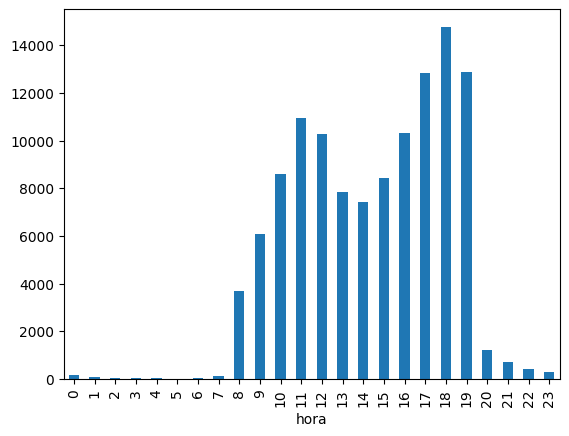

In [528]:
df_copy["hora"] = df_copy["Fecha"].dt.hour
df_copy["hora"].value_counts().sort_index().plot(kind="bar")

<Axes: xlabel='day_num'>

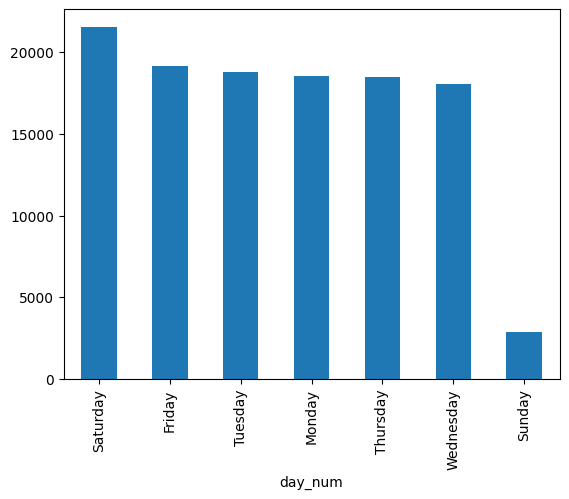

In [529]:
df_copy["day_num"] = df_copy["Fecha"].dt.day_name()
df_copy["day_num"].value_counts().plot(kind="bar")

<Axes: xlabel='Fecha'>

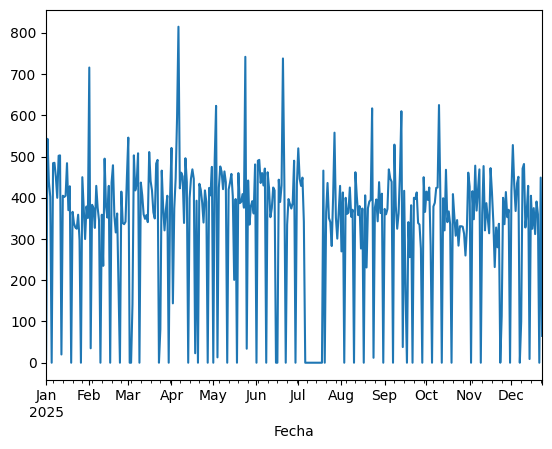

In [530]:
por_dia = df_copy.set_index("Fecha").resample("D").size()
por_dia.plot()

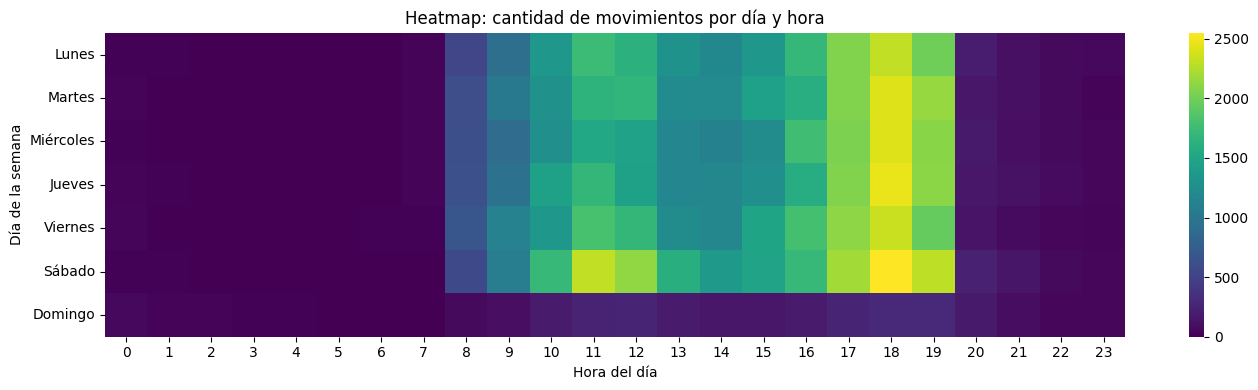

In [531]:
df_copy["day_num"] = df_copy["Fecha"].dt.dayofweek
df_copy["hour"] = df_copy["Fecha"].dt.hour

heat = pd.crosstab(df_copy["day_num"], df_copy["hour"])
heat = heat.reindex(index=range(7), columns=range(24), fill_value=0)

dias = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

plt.figure(figsize=(14, 4))
sns.heatmap(heat, cmap="viridis") 
plt.yticks(ticks=[i+0.5 for i in range(7)], labels=dias, rotation=0)
plt.xticks(rotation=0)
plt.xlabel("Hora del día")
plt.ylabel("Día de la semana")
plt.title("Heatmap: cantidad de movimientos por día y hora")
plt.tight_layout()
plt.show()

In [532]:
cat_variables.remove("Fecha")
cat_variables.remove("Producto")

<Axes: xlabel='Rubro', ylabel='count'>

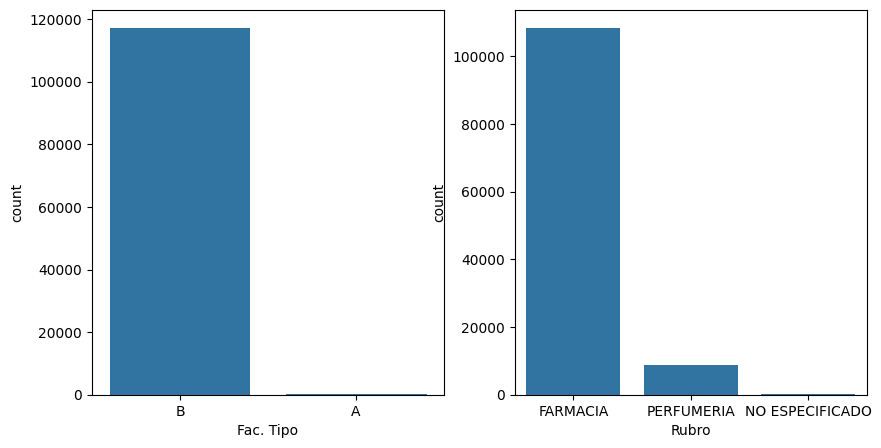

In [533]:
fig, axis = plt.subplots(1, 2, figsize=(10, 5))

sns.countplot(data=df, x=cat_variables[0], ax=axis[0])
sns.countplot(data=df, x=cat_variables[1], ax=axis[1])


#### Variable `Producto`

>Esta variable tiene muchos valores que son complicados de leer, como la trabajaremos a profundidad organizaremos y explicaremos en este espacio las decisiones que tomamos.
>
>Empezaremos por pasar todas las variables a minusculas y cambiar las ","(comas) por "."(puntos).

In [534]:
df["Producto"] = df["Producto"].fillna("").astype(str).str.lower().str.replace(",", ".", regex=False)
df["Producto"].value_counts()


Producto
gen lp ibuprofeno blister 600 mg x 10             1925
gen lp omeprazol blister 20 mg x 15               1203
aspirina prevent comp.cub.enterica x 50           1149
tafirol 1g x 8 (unica)                             870
tafirol 1 g comp.ran.x 50                          699
                                                  ... 
proair bronquial 500/50 cáps.p/inh.x 60+aplic.       1
flevomax 1000 mg comp.rec.x 30                       1
pampers pants premium care xgd                       1
aposito iqp (unica)                                  1
venda 7.5x2.5  (unica)                               1
Name: count, Length: 7672, dtype: int64

>Procederemos a borrar todos los productos que se vendieron menos de 100 veces en todo el año de datos que tenemos.
>Tambien haremos una revision a los nombres que tengan menos de 13 letras para verificar si queda algun error de tipografia donde no podamos sacar mas datos sobre el producto.

In [535]:
filtro_cant = 50  #Filtro de cantidad de ventas minimas en 1 año para afirmar que es factibla analizar
df = df[df["Producto"].map(df["Producto"].value_counts()) >= filtro_cant].copy()


In [536]:
mask = df["Producto"].fillna("").astype(str).str.len().le(12)
count_rows = mask.sum()
count_rows
df.loc[mask, "Producto"].astype(str).str.strip().value_counts()

Producto
dove (unica)    115
gum (unica)     108
Name: count, dtype: int64

In [537]:
df["Producto"].value_counts()

Producto
gen lp ibuprofeno blister 600 mg x 10      1925
gen lp omeprazol blister 20 mg x 15        1203
aspirina prevent comp.cub.enterica x 50    1149
tafirol 1g x 8 (unica)                      870
tafirol 1 g comp.ran.x 50                   699
                                           ... 
tervalon 5 mg comp.x 30                      50
sterogyl f.a.beb.x 2 ml                      50
poviral 800 mg comp.x 20                     50
actron cáps.gelat.blanda x 10                50
frenaler 5 mg comp.rec.x 14                  50
Name: count, Length: 499, dtype: int64

#### Observaciones

>Hasta este paso quitamos todos los productos que tuvieran menos de 12 ventas en todo el año y realizamos una revision de las variables que tuvieran menos de 12 letras, esto para filtrar los errores tipograficos como nombres cortos que no aporten nada. Aun asi no encontramos ninguno y continuamos.
>
>Nuestro siguiente paso es realizar una categorizacion a partir de la columna `Producto` donde crearemos la columna `product, dose, quantity` para clasificar los productos y poder entender mejor los datos.

In [538]:
df[["product", "dose", "quantity"]] = pd.NA

>Empezaremos poniendo las dosis segun los productos, para eso investigaremos sobre la nomenclatura de las dosis en argentina y crearemos un filtro que itere.

In [539]:
dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)                 # ✅ fix aquí
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w)
)"""

df["dose"] = df["Producto"].str.findall(dose_pat).str.join(", ")
df["dose"] = df["dose"].str.replace(r"(?i)(?<!\w)(unica|única)(?!\w)", "UNICA", regex=True)
df["dose"] = df["dose"].replace("", np.nan)


>Verificamos que productos quedan en blanco despues de nuestro filtro.

In [540]:
df[
    df["dose"].fillna("").eq("")
][["Producto", "Rubro", "dose"]].value_counts()

Series([], Name: count, dtype: int64)

In [541]:
df[["Producto", "dose"]].value_counts()

Producto                               dose     
gen lp ibuprofeno blister 600 mg x 10  600 mg       1925
gen lp omeprazol blister 20 mg x 15    20 mg        1203
tafirol 1g x 8 (unica)                 1g, UNICA     870
tafirol 1 g comp.ran.x 50              1 g           699
gen lp diclofenac blister 75 mg x 15   75 mg         530
                                                    ... 
lisovyr crema pomo x 5 g               5 g            50
frenaler 5 mg comp.rec.x 14            5 mg           50
gen lp enalapril blister 20 mg x 10    20 mg          50
poviral 800 mg comp.x 20               800 mg         50
cronopen 500 mg comp.rec.x 5           500 mg         50
Name: count, Length: 283, dtype: int64

>obtuvimos todas las dosis posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
>
>Ahora procederemos a trabajar la columna `quantity`.

In [542]:
prod = df["Producto"].fillna("").astype(str)

qty_pat = r"""(?ix)(
    
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b           

  
    \b(?:pomo|frasco|vial|amp(?:olla)?|sobre|sachet)\s*x?\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b

  
    \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b


    \bx\s*\d{1,4}\s*(?:ds|dosis)?\b


    \b\d{1,3}x\d{1,3}\b
)"""

df["quantity"] = prod.str.findall(qty_pat).str.join(", ")
df["quantity"] = df["quantity"].replace("", np.nan)


/tmp/ipykernel_4950/3579741549.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["quantity"] = df["quantity"].replace("", np.nan)


In [543]:
df[["Producto", "dose"]].value_counts().head(20)

Producto                                  dose     
gen lp ibuprofeno blister 600 mg x 10     600 mg       1925
gen lp omeprazol blister 20 mg x 15       20 mg        1203
tafirol 1g x 8 (unica)                    1g, UNICA     870
tafirol 1 g comp.ran.x 50                 1 g           699
gen lp diclofenac blister 75 mg x 15      75 mg         530
corbis 5 mg comp.rec.x 30                 5 mg          471
alikal (unica)                            UNICA         451
t4 montpellier 75 75 mcg comp.x 50        75 mcg        446
t4 montpellier 50 50 mcg comp.x 50        50 mcg        423
t4 montpellier 100 100 mcg comp.x 50      100 mcg       386
gen lp ibuprofeno blister 400 mg x 10     400 mg        368
acemuk 600 mg tab.eferv.x 10              600 mg        350
lotrial 10 mg comp.x 60                   10 mg         344
gen lp loratadina blister 10 mg x 10      10 mg         336
losacor 50 mg comp.rec.x 60               50 mg         306
carey (unica)                             UNICA 

>obtuvimos todas las cantidades posibles y donde no existia un valor medible directamente decidimos dejarla en blanco con un NaN.
>
>Ahora procederemos a trabajar la columna `product`.

In [544]:
prod = df["Producto"].fillna("").astype(str)

# --- 1) patrones a eliminar (dosis y cantidades/presentación) ---

dose_pat = r"""(?ix)(
    \b\d+(?:\.\d+)?\s*/\s*\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\s*/\s*\d+(?:\.\d+)?\s*(?:ml|g)\b
  | \b\d+(?:\.\d+)?\s*(?:mcg|µg|μg|ug|mg|g)\b
  | \b\d+(?:\.\d+)?\s*%(?!\w)
  | \b\d+\s*(?:dosis|ds)\b
  | (?<!\w)(?:unica|única)(?!\w)
)"""

qty_remove_pat = r"""(?ix)(
    \bx\s*\d+(?:\.\d+)?\s*(?:ml|cc|l|g|gr)\b
  | \b(?:pack|caja|env|sobre|sob|blister|blíster|test|aplic)\.?\s*x\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b(?:comp|comprimidos?|caps?|cáps?|grag|tab(?:s)?)(?:\.\w+)?\.?\s*x\s*\d{1,4}\b
  | \bx\s*\d{1,4}\s*(?:ds|dosis)?\b
  | \b\d{1,3}x\d{1,3}\b
)"""

# --- 2) base: quitar dose + quantity del texto ---
p = (prod
     .str.replace(dose_pat, " ", regex=True)
     .str.replace(qty_remove_pat, " ", regex=True)
)

# --- 3) FIXES específicos ---
# 3.1) quitar números sueltos al final (ej: "... seda 50" -> "... seda")
p = p.str.replace(r"(?ix)\s+\d{1,4}(?:\.\d+)?\s*$", " ", regex=True)

# 3.2) quitar 'x' suelta (ej: "cr x" -> "cr")
p = p.str.replace(r"(?ix)(?<!\w)x(?!\w)", " ", regex=True)

# 3.3) quitar el número repetido que coincide con la dosis (diurex 25 25 mg -> diurex)
dose_num = df["dose"].astype(str).str.extract(r"(\d+(?:\.\d+)?)", expand=False)

def drop_repeated_num(text, num):
    if not isinstance(num, str) or num == "" or num.lower() == "nan":
        return text
    return re.sub(rf"(?<!\w){re.escape(num)}(?!\w)", " ", text)

p = pd.Series(
    (drop_repeated_num(t, n) for t, n in zip(p.tolist(), dose_num.tolist())),
    index=df.index
)

# --- 4) limpieza final: puntuación y espacios ---
df["product"] = (p
    .str.replace(r"[^\w\sáéíóúñü]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .replace("", np.nan)
)

# opcional: colapsa repeticiones tipo "gel gel" -> "gel"
df["product"] = df["product"].str.replace(
    r"(?ix)\b(\w+)\b(?:\s+\1\b)+", r"\1", regex=True
)

In [545]:
df["product"].isna().sum()


np.int64(0)

In [546]:
import re
import unicodedata
import pandas as pd

# ---------- Helpers ----------
def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", s)
    return "".join(ch for ch in s if not unicodedata.combining(ch))

def norm(s) -> str:
    if pd.isna(s):
        return ""
    s = str(s).strip().lower()
    s = strip_accents(s)
    s = re.sub(r"\s+", " ", s)
    return s


EXACT = {
    
    "ibuprofeno": "ibuprofeno",
    "paracetamol": "paracetamol",
    "omeprazol": "omeprazol",
    "losartan": "losartán",
    "enalapril": "enalapril",
    "bisoprolol": "bisoprolol",
    "alprazolam": "alprazolam",
    "clonazepam": "clonazepam",
    "lactulosa": "lactulosa",
    "loratadina": "loratadina",
    "diclofenaco": "diclofenaco",
    "acetilcisteina": "acetilcisteína",
    "rosuvastatina": "rosuvastatina",
    "levotiroxina": "levotiroxina",
    "acido acetilsalicilico": "ácido acetilsalicílico",
    "acido acetilsalicilico + cafeina": "ácido acetilsalicílico + cafeína",
    "diclofenaco + pridinol": "diclofenaco + pridinol",
    "propinox + clonixinato de lisina": "propinox + clonixinato de lisina",
    "butilbromuro de hioscina + metamizol": "butilbromuro de hioscina + metamizol",
    "amoxicilina": "amoxicilina",
    "amoxicilina + acido clavulanico": "amoxicilina + ácido clavulánico",
    "colecalciferol (vitamina d3)": "colecalciferol (vitamina d3)",

    "tafirol": "paracetamol",
    "tafirol 500": "paracetamol",
    "tafirol forte": "paracetamol",
    "tafirol blister": "paracetamol",
    "geniol comp": "paracetamol",
    "mejoral paracetamol": "paracetamol",
    "paracetamol bayer": "paracetamol",
    "paracetamol raffo": "paracetamol",
    "paracetamol lazar": "paracetamol",
    "paracetamol teva": "paracetamol",

    "aspirina prevent comp cub enterica": "ácido acetilsalicílico",
    "bayaspirina": "ácido acetilsalicílico",
    "bayaspirina forte": "ácido acetilsalicílico",
    "aspirinetas": "ácido acetilsalicílico",
    "cafiaspirina": "ácido acetilsalicílico + cafeína",

    "t4 montpellier": "levotiroxina",
    "euthyrox": "levotiroxina",

    "lotrial": "enalapril",
    "corbis": "bisoprolol",
    "losacor": "losartán",
    "paxon": "losartán",
    "alplax": "alprazolam",
    "alplax net": "alprazolam",

    "rivotril": "clonazepam",
    "clonagin": "clonazepam",
    "clonagin sl": "clonazepam",
    "diocam": "clonazepam",
    "diocam sl": "clonazepam",

    "lactulon jbe": "lactulosa",

    "buscapina": "butilbromuro de hioscina",
    "buscapina fem": "butilbromuro de hioscina",
    "buscapina perlas": "butilbromuro de hioscina",
    "buscapina duo": "butilbromuro de hioscina",
    "buscapina duo got": "butilbromuro de hioscina",
    "buscapina compuesta": "butilbromuro de hioscina + metamizol",
    "buscapina compositum comp rec": "butilbromuro de hioscina + metamizol",

    "sertal": "propinox",
    "sertal perlas": "propinox",
    "sertal gts": "propinox",
    "sertal compuesto": "propinox + clonixinato de lisina",
    "sertal compuesto vl": "propinox + clonixinato de lisina",

    "ibupirac": "ibuprofeno",
    "actron 600 rapida accion caps gelat blanda": "ibuprofeno",
    "fabogesic 600 rapida accion cáps gelat blanda": "ibuprofeno",

    "acemuk": "acetilcisteína",
    "osteodyn": "colecalciferol (vitamina d3)",
    "osteodyn sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 sol oral": "colecalciferol (vitamina d3)",
    "raquiferol d3 100000 ui": "colecalciferol (vitamina d3)",
    "sterogyl f a beb": "colecalciferol (vitamina d3)",
    "sinlip": "rosuvastatina",

    "gadopril": "enalapril",

  
    "valium": "diazepam",
    "zoloft": "sertralina",
    "asertral": "sertralina",
    "lexotanil": "bromazepam",
    "lexapro": "escitalopram",
    "aropax": "paroxetina",
    "paxil cr": "paroxetina",
    "dramamine": "dimenhidrinato",
    "reliveran": "metoclopramida",
    "novalgina": "metamizol",
    "novalgina jbe": "metamizol",
    "bactrim": "sulfametoxazol + trimetoprima",
    "bactrim forte": "sulfametoxazol + trimetoprima",
    "glucophage": "metformina",
    "glucophage xr comp lib prol": "metformina",
    "dbi metformina": "metformina",
    "dbi ap metformina": "metformina",
    "forxiga": "dapagliflozina",
    "lipitor": "atorvastatina",
    "atorvastatin richet": "atorvastatina",
    "atorvastan": "atorvastatina",
    "ventolin hfa aer inh c": "salbutamol",
    "ventolin sol p nebul": "salbutamol",
    "salbutral aer": "salbutamol",
    "atrovent hfa aerosol hfa": "ipratropio",
    "seretide diskus dosis": "fluticasona + salmeterol",
    "symbicort turbuhaler dosis": "budesonida + formoterol",
    "anoro ellipta pvo inh": "umeclidinio + vilanterol",

    # Antibióticos marcas comunes
    "amoxidal": "amoxicilina",
    "amoxidal ped susp": "amoxicilina",
    "amoxidal duo": "amoxicilina + ácido clavulánico",
    "amoxidal duo susp": "amoxicilina + ácido clavulánico",
    "optamox duo": "amoxicilina + ácido clavulánico",
    "optamox duo susp": "amoxicilina + ácido clavulánico",
    "amixen clavulanico": "amoxicilina + ácido clavulánico",
    "amixen duo": "amoxicilina + ácido clavulánico",
    "amoclav duo": "amoxicilina + ácido clavulánico",
}


GENERIC_PATTERNS = [
    (r"\bibuprofeno\b", "ibuprofeno"),
    (r"\bparacetamol\b", "paracetamol"),
    (r"\bdiclofenac", "diclofenaco"),
    (r"\bnaproxeno\b", "naproxeno"),
    (r"\bketorolac\b", "ketorolac"),
    (r"\ballopurinol\b", "allopurinol"),
    (r"\batenolol\b", "atenolol"),
    (r"\bpropranolol\b", "propranolol"),
    (r"\bcarvedilol\b", "carvedilol"),
    (r"\bclopidogrel\b", "clopidogrel"),
    (r"\bmetformina\b", "metformina"),
    (r"\batorvastat", "atorvastatina"),
    (r"\brosuvastatina\b", "rosuvastatina"),
    (r"\bespironolactona\b", "espironolactona"),
    (r"\bfurosemida\b", "furosemida"),
    (r"\blosartan\b", "losartán"),
    (r"\benalapril\b", "enalapril"),
    (r"\bbisoprolol\b", "bisoprolol"),
    (r"\bomeprazol\b", "omeprazol"),
    (r"\blesomeprazol\b", "esomeprazol"),
    (r"\blevotiroxina\b", "levotiroxina"),
    (r"\bamoxicilina\b", "amoxicilina"),
    (r"\bcefalexina\b", "cefalexina"),
    (r"\bclindamicina\b", "clindamicina"),
    (r"\bciprofloxacina\b", "ciprofloxacina"),
    (r"\bnorfloxacina\b", "norfloxacina"),
    (r"\bazitromicina\b", "azitromicina"),
    (r"\bfluconazol\b", "fluconazol"),
    (r"\bnistatina\b", "nistatina"),
    (r"\bsildenafil\b", "sildenafil"),
    (r"\baciclovir\b", "aciclovir"),
    (r"\bcarbamazepina\b", "carbamazepina"),
    (r"\blamotrig", "lamotrigina"),
    (r"\bmemantina\b", "memantina"),
    (r"\bfinaster", "finasterida"),
    (r"\btamsulosina\b", "tamsulosina"),
    (r"\bsertralina\b", "sertralina"),
    (r"\bfluoxet", "fluoxetina"),
    (r"\bes(c|s)italopram\b", "escitalopram"),
    (r"\bparoxetina\b", "paroxetina"),
    (r"\bdiazepam\b", "diazepam"),
    (r"\bbromazepam\b", "bromazepam"),
    (r"\brisperid", "risperidona"),
    (r"\bquetiapin", "quetiapina"),
    (r"\bhaloperidol\b", "haloperidol"),
    (r"\bloratadina\b", "loratadina"),
    (r"\bdifenhidramina\b", "difenhidramina"),
    (r"\bsalbutamol\b", "salbutamol"),
    (r"\bipratropio\b", "ipratropio"),
    (r"\bfluticasona\b", "fluticasona"),
    (r"\bsalmeterol\b", "salmeterol"),
    (r"\bbudesonida\b", "budesonida"),
    (r"\bformoterol\b", "formoterol"),
    (r"\bmometasona\b", "mometasona"),
    (r"\bmetoclopramida\b", "metoclopramida"),
    (r"\bmetamizol\b", "metamizol"),
    (r"\bacetilcisteina\b", "acetilcisteína"),
    (r"\blactulosa\b", "lactulosa"),
    (r"\bcolecalciferol\b", "colecalciferol (vitamina d3)"),
    (r"\bcalcitriol\b", "calcitriol"),
    (r"\blidocaina\b", "lidocaína"),
    (r"\bterbinafina\b", "terbinafina"),
    (r"\bbeta(histina)?\b", "betahistina"),
    (r"\bdapaglifloz", "dapagliflozina"),
]


AMBIGUOUS = {
    "carey",
    "diurex", "diurex a",
    "qura", "qura plus",
    "migral", "migral ii", "migral compuesto", "migral compositum",
    "alikal", "alikal expend c prosp",
    "refrianex", "refrianex compuesto",
    "mylanta", "mylanta extra", "mylanta ii", "mylanta simple liq", "mylanta limon",
    "mylanta frut silv", "mylanta tabletas", "mylanta extra tableta",
    "supradyn forte", "supradyn pronatal", "supradyn forte eferv nar s az",
    "berocca plus",
    "uvasal sob doble", "uvasal naranja sob doble", "uvasal limon sob doble",
    "uvasal naranja fco", "uvasal fco plast",
    "next", "next forte", "next plus",
    "vick vitapyrena", "vick vitapyrena forte miel limon", "vick forte",
    "vick vaporub lata", "vick vaporub pote",
    "redoxon eferv limon", "redoxon eferv",
    "redoxitos plus sachets gomitas", "redoxitos naranja masticables sachets gomitas",
    "centrum mujer", "centrum silver",
    "corbis d", "lotrial d", "losacor a", "losacor d", "gadopril d",
    "paxon d", "losartan richet trzb",
}

# ---------- Mapeo ----------
def map_active(product_name: str):
    s0 = norm(product_name)
    if not s0:
        return "Desconocido", "empty"

 
    if s0 in AMBIGUOUS:
        return "Desconocido", "ambiguous_or_unknown"

    
    if s0.startswith("gen lp "):
        rest = s0.replace("gen lp ", "", 1).strip()
        rest = rest.replace("clavulanico", "acido clavulanico")

        if rest in EXACT:
            return EXACT[rest], "gen_lp_exact"

        for pat, active in GENERIC_PATTERNS:
            if re.search(pat, rest):
                return active, "gen_lp_pattern"

        return "Desconocido", "gen_lp_unresolved"

   
    if s0 in EXACT:
        return EXACT[s0], "exact"

  
    for pat, active in GENERIC_PATTERNS:
        if re.search(pat, s0):
            return active, "pattern"

 
    if re.search(r"\b(acc lp|perfumeria|accesorio|guantes|curita|curitas|barbijo|test|algodon|gasa|jeringa|venda|cepillo|colgate|dove|nivea|gillette|labello|listerine|rexona|ponds|garnier|pantene)\b", s0):
        return "Desconocido", "non_drug_or_device"

    return "Desconocido", "unknown"


mapped = df["product"].apply(map_active)


active = mapped.apply(lambda x: x[0])


mask = active != "Desconocido"
df.loc[mask, "product"] = active[mask]


print("Reemplazados:", int(mask.sum()))



Reemplazados: 26218


In [547]:
pharmaceutical_classifier = {
    'Salud Cardiovascular': ['alpertan', 'sartan', 'pril', 'olol', 'dipino', 'estatina', 'lipitor', 'lipokemia',
        'aspirina prevent', 'valsarfec', 'tervalon', 'ateronova', 'blokium', 'befol', 'furosemida', 'lipomax', 'combinater',
        'torivas', 'aspirinetas', 'racorval', 'atenolol', 'enalapril', 'amlodipina', 'rovartal', 'mecanyl', 'paraclim', 'oldren', 'lercadip',
        'losartan', 'amloc', 'cardio', 'aldactone', 'lotrial', 'simultan', 'arteriosan', 'nebicor', 'sarmec', 'lonikan', 'infiltrex', 'tetrazic',
        'diurex', 'rosustatin', 'rovastane', 'epistal', 'minuslip', 'regulip', 'medocor', 'bisofec', 'nebilet', 'tensimed',
        'carrier', 'meplar', 'losacor', 'prinil', 'lipifen', 'dilcoran', 'acalix', 'rosufen', 'syncrocor', 'letondal',
        'ateroclar', 'aturen', 'daunlip', 'espironol', 'filten', 'pelmec', 'rosufec', 'aclusin', 'tacicul', 'edagan',
        'bilip', 'bertel', 'nabila', 'corbis', 'diapresan', 'ixium', 'azecar', 'veraten', 'clopidogrel', 'astende',
        'acalik', 'atenix', 'indalten', 'glioten', 'diocam', 'meridian', 'dipemina', 'valpex', 'loctenk', 'zarator', 'loplac',
        'ilduc', 'bisopil', 'prisonil', 'sinlip', 'blavin', 'nivas', 'ultrex', 'vasotenal', 'antipresol', 'minicam', 'lasix',
        'sarval', 'atorvastatin', 'lostam', 'peptazol', 'vastarel', 'coracil', 'euretico', 'antiplaq', 'drimux',
        'ixacor', 'rosuvast', 'sistatin', 'tacardia', 'tanavat', 'renitec', 'crestor', 'flebosmina', 'enatral', 'pixaban',
        'montrate', 'corpres', 'endial', 'explaner', 'diural', 'pgb 75', 'diovan', 'togrel', 'clarimax', 'acantex',
        'aceno', 'acenocoumarol', 'alental', 'alipas', 'amix', 'amlodicord', 'amlodisane', 'amlopaw', 'aplacasse', 'aterva',
        'atucha', 'belozok', 'bempezet', 'benlipid', 'biascor', 'bicardil', 'bisofec', 'candesartan', 'cardionorm', 'cardiorex', 'carflax',
        'carvedil', 'carvedilol', 'cilos', 'cilostal', 'cilostazol', 'clodrel', 'clopilep', 'corosan', 'coroval', 'coverene', 'cozaarex', 'cristaclar',
        'oldinot', 'reovex', 'cvp flebo', 'drinax', 'atlansil', 'zocor', 'lipex', 'incoril', 'natrilix', 'irazem', 'rolast', 'plenacor', 'lopid', 'procardia', 
        'diondel', 'rostazina', 'policor', 'presimax', 'micardis', 'atorvastan', 'rosuber', 'tritab', 'tonibral', 'toltem', 'delak', 'pleyar', 'dilatrend', 'desaler', 
        'noster', 'sintrom', 'atarva', 'nifed sol', 'terloc', 'vytorin', 'rospower36', 'exforge', 'kemoter', 'pravil duncan', 'exforge', 
        'lonikan', 'infiltrex', 'tetrazic', 'lisaler', 'periplum', 'pivast', 'nodis', 'tencas', 'plidex', 'pravil duncan', 'exforge', 'verboril', 'zundic',
        'rentop', 'blastop', 'eplerona', 'nonlipid', 'novurit', 'gadocor', 'lagotran', 'etacril', 'sinaler', 'lebocar', 'evoquin',
        'vigicer', 'circuvit', 'recupel', 'sotacor', 'fenofibrato micronizado richet', 'rosucol', 'atacand', 'lunel 75 practidosis',
        'ristonel', 'vorst', 'craveril', 'hiperval', 'odranal', 'plidan', 'ezetrol', 'rociamin', 'vastina', 'firialta',
        'bigetric', 'duerix', 'nirpol', 'tritace', 'denverkast', 'treg', 'joker flex', 'finlipol', 'biorgan'],
    
    'Salud Mental / Sistema Nervioso': ['pisono', 'alplax', 'alprazolam', 'clonazepam', 'diazepam', 'fanter', 'lanx', 'equilibrane', 'remeron', 'topictal',
        'sertralina', 'fluoxetina', 'lexapro', 'psicoasten', 'quetiapina', 'somit', 'clonagin', 'trapax', 'noches', 'lucidex', 'eumotil',
        'lamotrigina', 'zepam', 'latrigin', 'paxon', 'risperin', 'novo', 'asertral', 'ivestron', 'madopar', 'taxagon ad', 'lamocas', 'meleril', 'dormiro',
        'psicotil', 'rivotril', 'tiarix', 'ampliar', 'ultraneural', 'migral', 'clonagin', 'trastocir', 'duxetin', 'trastocir', 'rostrum',
        'gavin', 'insertec', 'lextor', 'lexotanil', 'tranquinal', 'comenter', 'remizeral', 'aropax', 'quetiazic', 'discretal', 'quetiaros',
        'neuryl', 'emotival', 'serubel', 'valium', 'carbamazepina', 'memantina', 'zoloft', 'depakene', 'elafax', 'neuristan', 'cabal',
        'inductal', 'epamin', 'mestinon', 'melatol', 'armonil', 'modaton', 'climatix', 'audax', 'anafranil', 'tegretol', 'merital', 'sesaren',
        'actinerval', 'actison', 'akineton', 'alzepral', 'amiptril', 'ampk', 'anafranil', 'anelka', 'atemperator', 'biatrix', 'biperideno',
        'brintellix', 'ceglution', 'clonadane', 'clonax', 'conexine', 'conformal', 'consiv', 'continex', 'cuait', 'humorap', 'meleril', 'dormi-ros',
        'seroquel', 'neutop', 'deslafax', 'nocte', 'alprazol', 'afenexil', 'tueris', 'dominium', 'circonyl', 'lyrica', 'talpram', 'kanbis', 'optiser',
        'petrium', 'zentius', 'tryptanol', 'rediun', 'lamirax', 'audipax', 'ataraxone', 'paxil', 'donepes', 'mystika', 'rohypnol', 'pristiq', 'meibi',
        'valcote', 'dacten', 'lamictal', 'meprozin', 'etiasel', 'moperidona af', 'revertrix', 'aurene', 'rabloc', 'nitrodom', 'hipolipol',
        'neurontin', 'zenelis mareos', 'midax', 'xanax', 'zolodorm', 'lioresal', 'inquetia', 'rostalopram', 'valeriana', 'segren', 'kabian 100', 'equitone'],

    'Salud Digestiva': ['alumpak', 'alverin', 'almax', 'omeprazol', 'pantoprazol', 'reflux', 'dulcolax', 'gastromax', 'rogastril', 'miopropan', 'genoprazol', 'barex',
        'lanzoprazol', 'aci-tip', 'agarol', 'buscapina', 'bagohepat', 'lactulon', 'sinulcus', 'peptazol', 'esoprazol', 'deblax', 'anusol',
        'chofitol', 'bismuto', 'oligoplex', 'mylanta', 'taural', 'bicarbonato', 'qg5', 'sincerum', 'mudantil', 'reliveran', 'pantus', 'pantus',
        'alikal', 'sertal', 'regulane', 'axiomat', 'loperamida', 'ulcozol', 'lactulon', 'mutum', 'zoltenk', 'mebutar', 'remexal',
        'suerox', 'vorpix', 'aziatop', 'uvasal', 'rennie', 'hepatalgina', 'aglucide', 'acimed', 'esomepra', 'dexopral', 'antihemorroidal', 'prune iii', 'subical',
        'biletan', 'agiolax', 'reliveran', 'malvahp', 'genoprazol', 'gastromax', 'enterogermina', 'sucralfato', 'lorebil', 'dulcolax', 'actual comp', 'gastec',
        'aci-tip', 'acimed', 'agarol', 'agiolax', 'alverin', 'ansielix', 'apasmo', 'barex', 'carbogasol', 'carbon', 'cascara', 'ciruela', 'ciruelax', 'creon',
        'pantocas', 'eudon', 'paratropina', 'rempec', 'panastat', 'xilocler', 'fosfalax', 'ricino', 'bil', 'dramamine', 'lemil pvo', 'laxamin',
        'nikzon', 'urdecole', 'ilotcina', 'pantop', 'enemol', 'floratil', 'carmin', 'ilotcina', 'actual bl', 'plenica', 'desaler', 'lanzopral',
        'proctyl', 'spasmoctyl', 'laragon', 'iloticina', 'fosfo', 'diaris', 'nexium', 'sarmec', 'esodar', 'mosar', 'procto-ikatral', 'vermicet', 'pentasa', 'procto',
        'diar', 'vedipal', 'omecap', 'medilaxan', 'vecetam', 'nastizol', 'ultraprazol', 'lopecian', 'digecaps', 'molagar'],

    'Salud Sexual / Urología': ['nafil', 'dalafil', 'sildenafil', 'tadalafil', 'vimax', 'lubricante', 'invictus'],

    'Oftalmología': ['alphagan', 'ofta', 'colirio', 'timolol', 'latanoprost', 'lágrimas', 'idena', 'latlas', 'coltix', 'isis', 'flarex', 'latano',
        'gotas', 'tobrex', 'gatidex', 'soloftlmica', 'tobradex', 'sensu', 'natax', 'fotamicin', 'arlyt', 'plostim', 'flarex', 'tansiloprost',
        'restasis', 'systane', 'aucic', 'irix', 'opti free', 'gota pc', 'timed', 'quidex', 'coltix', 'latlas', 'gotabiotic', 'gtsoftx', 'lagrima',
        'acrylarm', 'alcon', 'alosol', 'arlyt', 'artelac', 'aucic', 'azarga', 'azopt', 'berlofen', 'bideon', 'eyes', 'brimopress', 'brit', 'brixia', 'cipos', 'closporil', 'coltix',
        'lagrimas', 'lagrima dorf', 'osiris sol', 'olopat', 'inmunosporin', 'glaucotensil', 'tears', 'tolf emuls', 'mirus sol', 'proflax', 'travatan',
        'ketif solx', 'glaucoprost', 'patanol', 'latanoflax', 'ocurel lc sol', 'ketif', 'newclar', 'isoptomax', 'ketif sol', 'isoptomax', 'tralerc lc',
        'fotadex', 'rifamicyn', 'tacines', 'dorlamida', 'lubrol', 'xalatan'],

    'Antibióticos': ['cilina', 'micina', 'floxacino', 'cicli', 'cef', 'amoxi', 'poviral', 'leflumax', 'nixoran', 'ivercass',
        'clavulanico', 'ceporexin', 'triamid', 'debril', 'nabratin', 'macril', 'bactrim', 'misultina', 'furadantina mc', 'dalacin c',
        'poviral', 'bactifren', 'leflumax', 'nixoran', 'azibiotic', 'flagyl', 'cronopen', 'dalacin c', 'urofuran', 'keforal',
        'acantex', 'acifusin', 'amikacina', 'amixen', 'amoclav', 'amoxicilina', 'amoxidal', 'amoxol', 'arotran', 'nexpeci', 'silfab pix',
        'asolmicina', 'avelox', 'azibiotic', 'azitromicina', 'azitrox', 'bactifren', 'bactrim', 'bioclavid', 'biotic', 'cefacar', 'cefalexina', 'cetaxim', 'ciriax',
        'claribiotic', 'clarimax', 'claritrom', 'claritromicina', 'clarovil', 'clavulox', 'clidan', 'clindacin', 'clindacur', 'clindamicina', 
        'xiclovir', 'pen di ben', 'nitrofurazona', 'estreptocarbocaftiazol', 'lisovyr', 'oralsone', 'metronidazol', 'nistatina',
        'nexpecil', 'rifadom', 'macromax'],

    'Antimicóticos': ['fluconazol', 'fangan', 'terekol', 'fungueal', 'micoral', 'itrac', 'terbenol duo', 'flupec', 'medifungol',
                      'perfungol', 'fungo nail', 'micotral', 'mycanden', 'ivertal'],

    'Analgésicos / Antiinflamatorios': ['profeno', 'fenaco', 'coxib', 'paracetamol', 'aspirina', 'fungocina', 'unesia', 'dorixina', 'mafel 200', 'diclo',
        'dol', 'clonixinato', 'mejoral', 'geniol', 'meloxicam', 'muelita', 'fabogesic', 'actron', 'next', 'tetralgin', 'sinalgico',
        'dioxaflex', 'ketorolac', 'tafirol', 'naprux', 'diclofenac', 'artrosil', 'anaflex', 'procetoken', 'liparex', 'gargaletas', 'serrapep',
        'prontal', 'ibu', 'evanol', 'diclomar', 'flogocox', 'bengue', 'ponstil', 'tetralgin', 'sinalgico', 'desinflamante', 'ernex', 'tryptalgin',
        'acloxigenac', 'actron', 'algicur', 'algispray', 'alikal', 'anaflex', 'arcoxia', 'arnica', 'artrosil', 'artrostop', 'aspirina', 'aspirinetas',
        'atomo', 'bayaspirina', 'befol', 'bengue', 'blokium', 'calmador', 'contractil', 'enantyum', 'migratriptan', 'predual', 'flexina', 'rodinac flex',
        'naprontag', 'rodinac', 'xumer', 'naprontag', 'diclogesic', 'naprontag', 'falgos', 'im 75 montpellier', 'fluticort', 'flumetol', 'lopred', 'otex hc',
        'otosporin', 'tetralg', 'talgiax', 'supracam', 'tetralg', 'talgiax', 'paravetamol', 'novalgina', 'ultragesic cb', 'flexresan'],

    'Salud Respiratoria / Antialérgicos': ['tadina', 'rizina', 'nasona', 'terol', 'ambroxol', 'mucol', 'frevia', 'alernix', 'aerotina', 
                                           'alercas', 'acemuk', 'aerius', 'frenadol', 'antigripal', 'ventolin', 'athos', 'relvar', 'neumocort', 
                                           'nasal', 'lukast', 'aliviatos', 'caramelos', 'refrianex', 'salbutamol', 'otoclean', 'novacler', 'pulmosan',
        'asmavitan', 'seretide', 'refenax', 'lidil', 'cedric', 'flutivent', 'collubiazol', 'pulmocler', 'salbutral', 'cetizine', 'refrianex', 'proetzonide',
        'acemuk', 'aerius', 'aerogal', 'aerolep', 'aerotina', 'aerotrop', 'aerovent', 'aeroxina', 'aireal', 'alergitrat', 'alermina', 'alerpriv', 'alertial',
        'aliviatos', 'anoro', 'aseptobron', 'asmabron', 'asmavitan', 'atrophen', 'atrovent', 'benadryl', 'bisolhelix', 'bisolvon', 'bronax', 'bronquisedan', 
        'bronsol', 'bucoangin', 'bucogel', 'bucotricin', 'budesonida', 'butocort', 'cedrimuc', 'cetriler', 'flixotide', 'kanbis sol oral', 'allegra', 'neumotide',
        'neumotex', 'filotricin', 'supraler', 'salbuden', 'lisi', 'symbicort', 'lafedryl', 'febratic', 'termofren', 'acc expectorante', 'incruse ellipta',
        'fluticort', 'flumetol', 'lopred', 'otex hc', 'neumotropio', 'aliviapres', 'decidex grip', 'resaquit', 'levomine', 'spiriva', 'decidex', 'proair bronquial',
        'expectosan antitusivo', 'febrigrip', 'ismigen', 'octanyl', 'rino-b nebu', 'tukol ac', 'tukol miel y tomillo', 'pulmonix grip','tukol buc miel',
        'kipergrip', 'plenair'],

    'Antialérgicos': ['dexalergin', 'hexaler', 'frenaler', 'difenhidramina', 'cortipyren'],

    'Higiene y Cuidado Personal': ['shampoo', 'acondicionador', 'jabon', 'desodorante', 'axe', 'st ives', 'fluordent', 'plac out', 'dentilac', 'evagina', 'trim', 'gel',
        'dove', 'colgate', 'pasta dental', 'cepillo', 'hilo dental', 'gillette', 'listerine', 'venus', 'tuly',
        'enjuague bucal', 'protector', 'neutrogena', 'dermaglos', 'ensure', 'nopucid', 'sapolan', 'lux botan jazmin',
        'aderma', 'aveno', 'cerave', 'vichy', 'la roche', 'cicatricure', 'OB', 'issue', 'malva',
        'lactacyd', 'asepxia', 'biferdil', 'capilatis', 'cutex', 'idi', 'medicasp', 'ortodoncia',
        'siempre libre', 'always', 'carefree', 'softpicks', 'rexona', 'cepillo', 'glicerina', 'millefiori microondas',
        'close', 'proxa', 'johnson', 'carey', 'pantene', 'nivea', 'hinds', 'tresemmé', 'esmalte',
        'labello', 'clear', 'corega', 'flossers', 'discos', 'farmacolor', 'esmalte', 'cortauas',
        'dermagls', 'eumicel', 'libre', 'listerine', 'gum', 'tresemme', 'veet', 'ciel', 'difusor', 'cisne beauty', 'mas cisne color',
        'escofina', 'eva gina', 'toallitas', 'sensodyne', 'piroctol', 'desodorante', 'algodón', 'veritas',
        'dermagls', 'nosotras', 'kevin black', 'kevin absolute', 'kevin park', 'kevin ice', 'mujercitas', 'agua de azahar',
        'tio nacho', 'manteca', 'borato', 'squam', 'kritel', 'inecto', 'orde', 'foot', 'solar', 'oral b', 'azucena',
        'acneique', 'acnesan', 'acnetrol', 'acnoxin', 'acondicionador', 'aderma', 'adermicina', 'aloebel', 'alumpak', 'atrix', 'avene', 'avixis', 'bagovit',
        'batiste', 'biokeratin', 'blefaskin', 'brown', 'bucaltac', 'buchex', 'bushi', 'butler', 'caladryl', 'capilex', 'capillaire', 'cetaphil',
        'cleanex', 'clear', 'men', 'clericot', 'cocot', 'colonia', 'cutex', 'preal', 'dentilac', 'depilmiel', 'depilorm', 'depimiel', 'deralbine', 'dercolina',
        'derm', 'dermacler', 'dermadex', 'dermaglos', 'especial', 'lima', 'old spice', 'goicoechea', 'elite disney pocket',
        'acf by dadatina', 'ponds', 'dots frutos', 'plenitud', 'lux unica', 'fulton (unica)', 'gillete sensitive',
        'mordillo extra refrigerante', 'natura express', 'acc lp pasta lasar', 'adult care', 'bromhistop',
        'off (unica)', 'zalea', 'colitas (unica)', 'crema (unica)', 'feen a mint', 'eucerin aquaphor', 'peine unica', 'colitas', 
        'dots frutillas', 'off extra duracion', 'unifresh limpiador', 'labial unica', 'evo unica', 'skyn unica', 'azucen'
        'esfumel', 'noc 10 concentrada', 'tena discreet', 'foto ultra age repair', 'esfumel blanqueadora', 'uelos (unica)',
        'lux (unica)', 'lidclean', 'off defe', 'esponja', 'feen a mint', 'garnier agua mic', 'tulipan super finos', 
        'piedra pomez', 'tena pants', 'PA�O', 'impulse musk', 'yeruti torta', 'tulipan', 'skyn', 'emal diaman', 'pañuelos', 'pañuelitos',
        'lubrol clean', 'emoform', 'pao unica', 'heno de pravia', 'colita', 'nail (unica)', 'labial (unica)', 'evo (unica)',
        'satin (unica)', 'talquera', 'talco veritas', 'oral b (unica)', 'ozono (unica)', 'SKIM', 'umasam jab', 'elite',
        'pañuelos', 'talco', 'lux botan orq negra', 'off family crema', 'greta', 'sen', 'labial mate', 'labial larga duracion', 
        'coronet metali', 'oral b unica', 'mas broch', 'lux botan orq negra', 'off family crema', 'greta', 'sen', 'labial mate', 'labial larga duracion', 
        'lux botan france rep', 'mascara', 'esmalt (unica)', 'lux botan lirio azul', 'paula luz', 'tortulan desmaq bifasico', 'loreal base', 'maybelline fire work',
        'garnier skin act bifa agua mic', 'solvente', 'delineado lapiz', 'tulioan', 'lapiz corrector'],

    'Accesorios y Dispositivos Médicos': ['pañal', 'huggies', 'pampers', 'toalla', 'algodon', 'jeringa', 'collar', 'espejo',
        'aguja', 'preservativo', 'condon', 'test', 'termometro', 'soft', 'comodin', 'inconti', 'latex', 'omron automat', 'fashion (unica)',
        'curitas', 'accesorio', 'barbijo', 'maxx', 'broche', 'espermicida', 'prime', 'franklin', 'pastillero', 'toma presion',
        'almohada', 'almohadilla', 'arquador', 'aspirador', 'assy', 'atucha', 'innovation', 'bajalenguas', 'pinza (unica)',
        'barbajo', 'barbijo', 'bisturi', 'bolsa', 'botiquin', 'broche', 'cepillo', 'chata', 'cinta', 'colector', 'comodin', 
        'contour', 'cortapastilla', 'cortaunas', 'cotonetes', 'curita', 'dedal', 'dedo', 'delineador', 'pastillero', 'gorro ducha',
        'accesorio', 'textil', 'faja', 'peine', 'alicate', 'tijera', 'accesesorios', 'maverick digital', 'pera unica', 'bandaid', 'procer',
        'pera', 'traspore', 'organizador', 'mas pinza', 'vinchas', 'sol fis', 'estuche', 'vortex aerocamara', 'pulsera', 'brazalete'],

    'Nutrición y Suplementos': ['magnesio', 'vitamina', 'suplemento', 'ensure', 'pediasure', 'linus', 'control k',
        'bagovit', 'centrum', 'berocca', 'supradyn', 'acifol', 'hierro', 'nutrilon', 'ostelin', 'vitalix', 'crafine', 'magnal',
        'calcio', 'soloral', 'osteodyn', 'omega', 'chia', 'colageno', 'tapones', 'dbi', 'tanvimil', 'ajo', 'kaon elixir', 'fer in sol',
        'artrostop', 'curflex', 'b12', 'becozym', 'redoxon', 'bernafolic', 'glucerna', 'magnesiano', 'capskrill', 'estrella', 'lactibon', 'merital',
        'devisal', 'sterogyl', 'raquiferol', 'oravil', 'larotabe', 'quelat', 'siderblut', 'gadoferol', 'valcatil', 'allopurinol',
        '102', 'mujer', 'plus', 'sport', 'acifol', 'aminoterapia', 'anemidox', 'anfolic', 'arandano', 'arginina', 'azidac', 'b1', 'b6',
        'b12', 'bago+', 'berocca', 'bisglicinato', 'blue-vit', 'blueking', 'fort', 'cal', 'vita', 'calcimax', 'calcio', 'calciocit', 'calcional', 'calcitriol', 
        'cartilago', 'centrum', 'chia', 'chiacaps', 'ciagen', 'oil', 'colageno', 'curcuma', 'food', 'chuker', 'espesan', 'egestan folico',
        'vientre plano', 'trip d3', 'exertial', 'citrato de maganesio', 'maternil', 'framintrol', 'satial carb controller',
        'ferinjec', 'kaon elixir', 'natuliv', 'piedra china', 'resveratrol francelab', 'colmibe', 'gen lp carb', 'metabolic cla', 'priotic',
        'iu 400', 'ferrologic', 'cados', 'ferinject', 'de india', 'spirulina', 'garcinia', 'venofer', 'cuasia amarga', 'metabolic max', 'generday equilibrio',
        'i.u. 400', 'sacarina', 'ultraflex', 'ferive', 'pharmaton essential', 'sucaryl', 'caramelo (unica)', 'tri vi sol'],

    'Diabetes y Endocrino': ['metformina', 'insulina', 'glibenclamida', 'levotiroxina', 'glucophage', 'danantizol', 'nexdia',
        't4', 'glucosa', 'glucogood', 'forxiga', 'islotin', 'diamicron', 'aglucide', 'siaglix', 'zomarist', 'imecot', 'glemaz',
        'aglucide', 'agliptin', 'azatioprina', 'dagliben', 'dbi', 'glifosin', 'trayenta', 'januvia', 'enclyna', 'glidanil', 'neurotioct',
        'accu','diabo', 'diabesil ap', 'accuchek guide tiras reactivas', 'metglucon', 'diabesil', 'victoza', 'dapax', 'jardiance', 'euglucon'],

    'Material de Curación': ['guante', 'gasa', 'iruxol', 'iodopovidona', 'estéril', 'envase', 'curita', 'venda', 'aplicacion', 'curita', 'venda', 'aplicacion',
        'antialérgica', 'tela', 'merthiolate', 'anestésico', 'ox', 'fisiológica', 'alibour', 'fisiologica', 'hipoalergic', 'curita', 'tubos',
        'apositos', 'transpore', 'bandaid', 'aposito', 'band-aid', 'band aid', 'alcohol'],

    'Gripe': ['qura', 'rhinal', 'ventonil'],

    'Dermatología': ['paldar', 'megacistin', 'deralbine', 'vaselina', 'empecid', 'mupax', 'keratopic', 'louten', 'erisol', 'sinamida', 'klomadex',
        'cremtotal', 'hipoglos', 'diabet', 'betacort', 'factor', 'platsul', 'perpiel', 'piecidex', 'dermexane', 'caladryl', 'salil', 'teatrical',
        'dermagls', 'dermagls', 'dermexane', 'caladryl', 'gentaderm', 'filtres', 'fenosane', 'procetoken','dermagls solar', 'vitacortil', 'verruclean',
        'acneclin', 'verrutopic', 'flebosmina', 'abralux', 'acler', 'acneique', 'acnesan', 'acnetrol', 'acnoxin', 'adapne', 'adermicina', 'algicler', 'aristaloe', 
        'arzimol', 'asepxia', 'atopix', 'aurea', 'avixis', 'bacticort', 'bengue', 'benzihex', 'bepanthol', 'betacort', 'betasalic', 'betnovate', 'betriol', 
        'cicanol', 'cicatricure', 'clevosan', 'clidan', 'clindacin', 'clindacur', 'clobesol', 'contractil', 'oremañe', 'cuta', 'cutanit', 
        'denvercrem', 'dercolina', 'derma', 'dermadex', 'dermaglos', 'microsona', 'hifamonil', 'farm', 'salac', 'micolis', 'fitonal', 'micosep',
        'actual compmastx', 'finescar spray', 'metral', 'cicaplast', 'isdin', 'tetralysal', 'mometax', 'serocutin', 'tresite', 'xegrex',
        'soolantra', 'fripi', 'grisovin', 'gentaso', 'pitiriax', 'prurisedan', 'ivercrem', 'fripi flash', 'lupan', 'fusimed b', 'verrugol',
        'securo', 'tacrotic', 'acc lp azufre', 'salicor', 'fusimed', 'pasta al agua', 'hexa defital', 'miquimod', 'tacro-tic', 'alfacort',
        'neotretin m', 'diprogenta', 'masivol', 'licend', 'espuma (unica)', 'lrp mela b3', 'acerpes', 'diabecler', 'efitum', 'miklogen', 'isotan', 'lacorene'],

    'Ginecológico / Salud Femenina': ['fucsia', 'diva', 'colpofilin', 'vagisil', 'ovufem', 'elektra', 'umma', 'levogest', 'isis free', 'yaz', 'kala', 'ginkan', 'vagilen',
                                      'damsella', 'norgestrel', 'divina', 'cerazette', 'amapoli', 'miranda', 'nor', 'fenogynol', 'camelia', 'kali', 'ovata',
                                      'gadofem', 'torgyn', 'colpoestriol', 'femiden', 'damsel', 'slinda', 'ginelea', 'ob', 'diane', 'isis', 'micoclin', 'tricofin',
                                      'ronfase', 'kir', 'ovulos', 'doncella', 'lactamax', 'rubi', 'secret', 'jade', 'aleli', 'yasmin', 'ovumix', 'evacare',
                                      'femexin', 'evra parches', 'mirena', 'ciclocur', 'desire', 'zinnia', 'plan', 'ginal cent', 'prebien', 'metrergina', 'florence',
                                      'zinnia', 'plan', 'ginal cent', 'colpotrophine', 'viasek', 'genozym', 'qlaira', 'microvlar', 'nulipar',
                                      'eucerin intim protect', 'lomeca', 'gino deo', 'tabcin compuesto', 'nulipar', 'cuidafe', 'crada', 'ovulol ud',
                                      'progest', 'promeclim', 'honguil', 'femalvi', 'miranova', 'mesigyna', 'colpoestriene', 'femterona', 'fungototal gyno'],

    'Fragancia': ['cuore', 'pepas', 'paco', 'colbert', 'pink', 'kevin', 'mujercitas', 'edt', 'edp', 'colonia', 'vapo', 'boos', 'herrera', 'perfumeria',
                  'perfumina', 'prune moi', 'kerzen perfu', 'prune i aero', 'paula alegria', 'paula alma', 'impulse true love', 'perfume'],

    'Vascular': ['daflon', 'aliviafleb', 'diosmin', 'reagin vascular', 'reagin', 'venart', 'flevomax', 'varisedan', 'cyclo 3'],

    'Urología': ['reduprost', 'urocont', 'prostoklar', 'duodart', 'sulos', 'magnus', 'urifex', 'finasterin', 'uralos', 'minocass', 'avodart', 'dutapil',
                 'omnic', 'ditropan', 'tarusol', 'permicaps', 'darisec', 'andrin', 'urosedac', 'ursomax', 'cistalgina', 'urokit', 'aclosan', 'triurol', 'dutaklar',
                 'denverprost', 'dutasinar', 'uroseptal', 'ludasterin', 'urginol', 'colpuril a retard'],

    'Otorrino': ['meniex', 'otosan', 'betahistina'],

    'Reumatología': ['brek', 'marvil', 'asotrex', 'ibandronato', 'artrait', 'polirreumin', 'colchicina houde', 'femorel', 'derrumal', 'prolia',
                     'oseum', 'artrodar', 'ribastamin'],

    'Corticoides': ['deltisona', 'corticas', 'cronocorteroid', 'decadron', 'corteroid', 'metilpres', 'duo decadron', 'corteroid retard', 'dexa',
                    'dexatotal', 'celestone', 'suavicort', 'hidrotisona', 'meprednisona', 'demacort', 'hidrotisona', 'deltacort'],

    'Cuidado Capilar:': ['shampoo', 'acondicionador', 'biferdil', 'capilatis', 'inecto', 'nacho', 'pantene', 'tresemme', 'folcres', 'panten', 'sedal liso perfecto', 
                         'elvive ha pure', 'micoral sham', 'garnier vit c', 'anagen', 'elvive oleo', 'propecia', 'lord cheseline', 'matizador', 'sorsis shampx',
                         'salpad t shamp', 'sedal ceramidas', 'tres emme', 'sorsis shamp', 'head shoul', 'sedal co-creations', 'nic re viviendo',
                         'quadion', 'elvive glycolic gloss', 'elvive hidra hialuronico', 'sedal', 'sedal luminoso uv', 'head sho limpieza ac argan',
                         'head  sho'],

    'Cuidado Bucal:': ['colgate', 'sensodyne', 'bucaltac', 'enjuague', 'dental', 'corega', 'odor control', 'elmex', 'plax zero', 'sea bond'],

    'Protección Solar': ['solar', 'fps', 'autobronceante', 'post', 'ozono f50', 'fotosol', 'rayito', 'eryfotona akn', 'spf', 'fusion water', 'eryfotona ak', 
                         'eucerin f50 hydro fluido', 'solenil lips protect', 'loreal uv'],

    'Vacunas y Biológicos': ['qdenga', 'bexsero', 'shingrix', 'infanrix', 'pneumovax', 'vacuna antitetanica', 'vacuna', 'influvac tetra', 'flucelvax quad',
                             'istivac 4'],

    'Endocrino': ['t3 montpellier'],

    'Bebés y Maternidad': ['nan sin lactosa', 'mamadera', 'termokids', 'chupete', 'chup', 'vaso aprendizaje', 'petit enfant bebe', 'pañales', 'sancor bebe',
                           'ig fit extra absorbente', 'scf 551/05 vaso easy sip', 'tetinas'],
}

In [548]:
def assign_category(name):
    name = str(name).lower()
    for category, names in pharmaceutical_classifier.items():
        for word in names:
            if word in name:
                    return category
    return 'Otros'

df['groups'] = df['Producto'].apply(assign_category)

mask = df['groups'].isin(['Otros', 'Unknown'])

df.loc[mask, 'groups'] = df.loc[mask, 'Producto'].apply(assign_category)

In [549]:
df[["product"]].value_counts()

product               
ibuprofeno                3411
levotiroxina              3053
paracetamol               2821
ácido acetilsalicílico    1625
clonazepam                1291
                          ... 
tervalon                    50
lisovyr crema pomo          50
cronopen                    50
poviral                     50
acc lp aguja                50
Name: count, Length: 355, dtype: int64

In [550]:
(df["product"] != "Desconocido").sum()


np.int64(62500)

In [551]:
df.drop(columns=["quantity"], errors="ignore", inplace=True)

### Analisis de variables numericas

In [552]:
num_variables = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
num_variables

['Fac. Suc.',
 'Fac. Nun.',
 'Cant.',
 'Precio',
 'Sub. Total',
 'Cobertura',
 'Ajustes',
 'Desc. Adic.',
 'Total. Cliente',
 'IVA',
 'Tasa Iva',
 'Total Gravado',
 'Total sin Gravar',
 'year',
 'num_semana']

In [553]:
df[num_variables].describe().T

,count,mean,std,min,25%,50%,75%,max
Fac. Suc.,62500.0,0.000000,0.000000,0.00,0.0000,0.000,0.000,0.00000
Fac. Nun.,62500.0,417197.304992,22221.546559,379923.00,398020.5000,415550.500,436823.000,455862.00000
Cant.,62500.0,1.447888,1.857468,0.00,1.0000,1.000,1.000,48.00000
Precio,62500.0,12550.528101,11465.530354,30.00,4600.0000,8670.200,16463.000,117152.35000
Sub. Total,62500.0,12944.473282,12389.625419,0.00,4850.0000,8670.460,16572.710,205156.84000
Cobertura,62500.0,5924.047371,10211.009893,-157953.92,0.0000,0.000,8717.370,141784.74000
Ajustes,62500.0,0.000000,0.000000,0.00,0.0000,0.000,0.000,0.00000
Desc. Adic.,62500.0,14.474386,317.134569,-31312.40,0.0000,0.000,0.000,14380.43000
Total. Cliente,62500.0,7005.951525,6636.385330,0.00,2924.0450,5394.544,8980.276,178298.57000
IVA,62500.0,119.712332,431.747475,0.00,0.0000,0.000,0.000,27768.59504


In [554]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Fecha,62500,2025-06-23 07:12:00.700928,2025-01-01 01:13:46,2025-03-28 19:29:43.249999872,2025-06-13 17:37:02,2025-09-20 16:20:05,2025-12-23 10:25:57,NaN
Fac. Suc.,62500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Fac. Nun.,62500.0,417197.304992,379923.0,398020.5,415550.5,436823.0,455862.0,22221.546559
Cant.,62500.0,1.447888,0.0,1.0,1.0,1.0,48.0,1.857468
Precio,62500.0,12550.528101,30.0,4600.0,8670.2,16463.0,117152.35,11465.530354
Sub. Total,62500.0,12944.473282,0.0,4850.0,8670.46,16572.71,205156.84,12389.625419
Cobertura,62500.0,5924.047371,-157953.92,0.0,0.0,8717.37,141784.74,10211.009893
Ajustes,62500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Desc. Adic.,62500.0,14.474386,-31312.4,0.0,0.0,0.0,14380.43,317.134569
Total. Cliente,62500.0,7005.951525,0.0,2924.045,5394.544,8980.276,178298.57,6636.38533


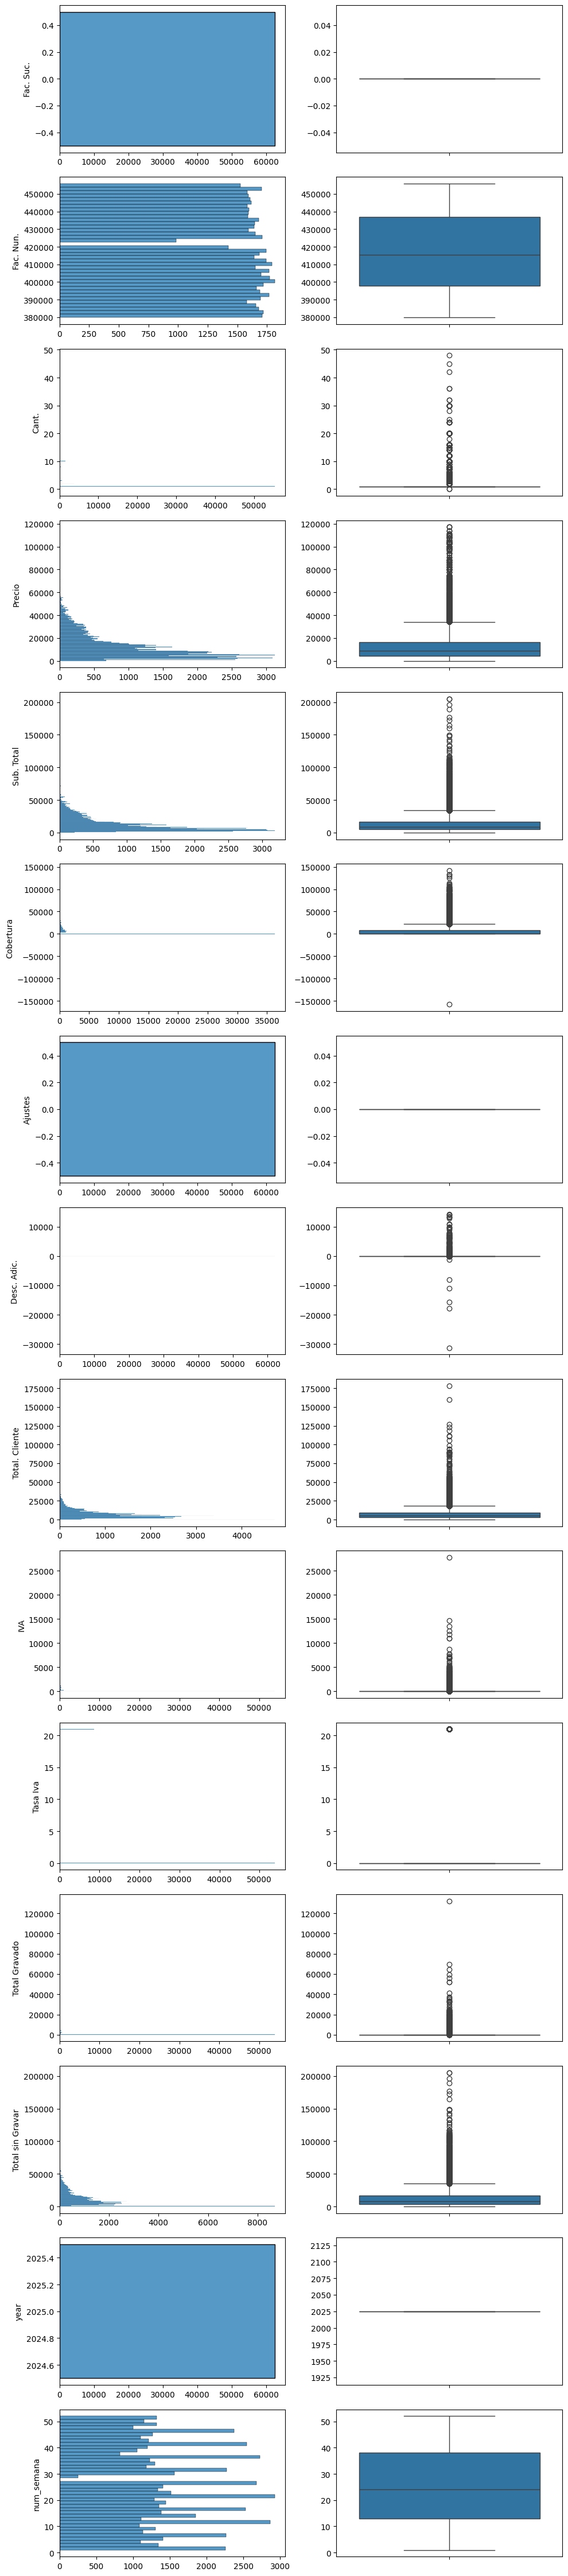

In [555]:
fig, axis = plt.subplots(len(num_variables), 2, figsize=(10, 3*len(num_variables)))

for i, var in enumerate(num_variables):
    sns.histplot(ax=axis[i, 0], data=df, y=var).set(xlabel=None)
    sns.boxplot(ax=axis[i, 1], data=df, y=var).set(ylabel=None)


plt.tight_layout()
plt.show()

#### Observaciones.

`Fac. Suc.` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Fac. Nun.` - Es el numero de factura, como un id, tampoco nos aporta mucho a lo que buscamos.    
`Cant.` - Aunque la mayoria tienen como valor 1, el resto de outliner parecen ser reales, la conservaremos para tratarla detalladamente mas adelante.  
`Precio` - Es el precio por unidad que tiene un producto  
`Sub. Total` - Es el resultado de multiplicar el precio por cantidad   
`Cobertura` - Es lo que cubre la seguridad social.   
`Ajustes` - Todos sus valores estan en 0, en una columna que no nos dice nada.  
`Desc. Adic.` - Aunque la mayoria de los valores estan en 0, tiene numeros en negativos y positivos, tambien revisaremos a profundidad.  
`Total. Cliente` -  La mayoria de valores esta entre 0 y 25000, tiene varios outliners que debemos tomar en cuenta.  
`IVA` -  Esta variable va desde el 0 al 160000, tiene sentido ya que sera el iva por producto.  
`Tasa Iva` - esta entre 0, 10% y 21%    
`Total Gravado` -  los valores principalmente estan en 0, pero notamos algunos outliners que revisaremos a detalle  
`Total sin Gravar` -   Los valores estan entre 0 y 60000 aproximadamente, encontramos varios outliners que analizaremos lo que nos dice mas adelante.  

In [556]:
df = df.drop(columns=["Fac. Suc", "Fac. Nun.", "Ajustes"], errors="ignore")

In [557]:
df[["Producto", "Precio", "Sub. Total", "Cant.", "Cobertura", "Desc. Adic.", "Tasa Iva", "IVA","Total Gravado", "Total sin Gravar", "Total. Cliente"]].head(10)

,Producto,Precio,Sub. Total,Cant.,Cobertura,Desc. Adic.,Tasa Iva,IVA,Total Gravado,Total sin Gravar,Total. Cliente
0,actron pediatrico 4% susp.oral x 100 ml,9344.00,9344.00,1,0.00,0.0,0,0.000000,0.000000,9344.00,9344.00
1,amoxidal 500 mg comp.rec.x 21,8174.96,8174.96,1,3032.85,0.0,0,0.000000,0.000000,8174.96,5142.11
2,amoxidal 500 mg comp.rec.x 21,8174.96,8174.96,1,5318.10,0.0,0,0.000000,0.000000,8174.96,2856.86
6,gen lp ketorolac blister 20 mg x 10,4800.00,4800.00,1,0.00,0.0,0,0.000000,0.000000,4800.00,4800.00
7,cafiaspirina plus comp.x 20,4961.00,4961.00,1,0.00,0.0,0,0.000000,0.000000,4961.00,4961.00
8,accesorio (unica),3500.00,7000.00,2,0.00,0.0,21,1214.876033,5785.123967,0.00,7000.00
9,qura plus comp.rec.x 20,3430.00,3430.00,1,0.00,343.0,0,0.000000,0.000000,3430.00,3087.00
13,acc lp gasa esteril no 5 caja 10 x 10,4500.00,4500.00,1,0.00,0.0,21,780.991736,3719.008264,0.00,4500.00
14,acc lp guantes latex par,300.00,900.00,3,0.00,0.0,21,156.198347,743.801653,0.00,900.00
15,acc lp agua oxigenada 10 vol\tx 100 cc,1000.00,1000.00,1,0.00,0.0,21,173.553719,826.446281,0.00,1000.00


### Observaciones. Hasta este punto tenemos informacion suficiente para poder, según el modelo y el target, usar los datos para hacer predicciones de ML.

## Objetivos o targets a predecir.

### Objetivo 1: Predecir cantidad de productos vendidos por semana.

>Con los datos que tenemos nos parece viable hacer predicciones de ventas de productos. Ajustaremos y limpiaremos el DataSet en una copia para dejar los datos que tenemos hasta aca para otro tipo de predicciones.

In [558]:
df_obj_one = df.copy()

In [559]:
df_obj_one.head(10)

,Fecha,Fac. Tipo,Fac. Suc.,Cant.,Precio,Producto,Sub. Total,Rubro,Cobertura,Desc. Adic.,...,Tasa Iva,Total Gravado,Total sin Gravar,year,num_semana,week_start,week_end,product,dose,groups
0,2025-01-01 01:13:46,B,0,1,9344.00,actron pediatrico 4% susp.oral x 100 ml,9344.00,FARMACIA,0.00,0.0,...,0,0.000000,9344.00,2025,1,2024-12-30,2025-01-05,actron pediatrico susp oral,4%,Analgésicos / Antiinflamatorios
1,2025-01-01 01:59:21,B,0,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,FARMACIA,3032.85,0.0,...,0,0.000000,8174.96,2025,1,2024-12-30,2025-01-05,amoxicilina,500 mg,Antibióticos
2,2025-01-01 02:01:59,B,0,1,8174.96,amoxidal 500 mg comp.rec.x 21,8174.96,FARMACIA,5318.10,0.0,...,0,0.000000,8174.96,2025,1,2024-12-30,2025-01-05,amoxicilina,500 mg,Antibióticos
6,2025-01-01 06:22:37,B,0,1,4800.00,gen lp ketorolac blister 20 mg x 10,4800.00,FARMACIA,0.00,0.0,...,0,0.000000,4800.00,2025,1,2024-12-30,2025-01-05,ketorolac,20 mg,Analgésicos / Antiinflamatorios
7,2025-01-01 06:22:37,B,0,1,4961.00,cafiaspirina plus comp.x 20,4961.00,FARMACIA,0.00,0.0,...,0,0.000000,4961.00,2025,1,2024-12-30,2025-01-05,cafiaspirina plus,NaN,Analgésicos / Antiinflamatorios
8,2025-01-01 07:46:36,B,0,2,3500.00,accesorio (unica),7000.00,FARMACIA,0.00,0.0,...,21,5785.123967,0.00,2025,1,2024-12-30,2025-01-05,accesorio,UNICA,Accesorios y Dispositivos Médicos
9,2025-01-02 08:08:38,B,0,1,3430.00,qura plus comp.rec.x 20,3430.00,FARMACIA,0.00,343.0,...,0,0.000000,3430.00,2025,1,2024-12-30,2025-01-05,qura plus,NaN,Nutrición y Suplementos
13,2025-01-02 08:44:01,B,0,1,4500.00,acc lp gasa esteril no 5 caja 10 x 10,4500.00,FARMACIA,0.00,0.0,...,21,3719.008264,0.00,2025,1,2024-12-30,2025-01-05,acc lp gasa esteril no 5 caja,NaN,Material de Curación
14,2025-01-02 08:44:01,B,0,3,300.00,acc lp guantes latex par,900.00,FARMACIA,0.00,0.0,...,21,743.801653,0.00,2025,1,2024-12-30,2025-01-05,acc lp guantes latex par,NaN,Accesorios y Dispositivos Médicos
15,2025-01-02 08:44:01,B,0,1,1000.00,acc lp agua oxigenada 10 vol\tx 100 cc,1000.00,FARMACIA,0.00,0.0,...,21,826.446281,0.00,2025,1,2024-12-30,2025-01-05,acc lp agua oxigenada 10 vol,NaN,Material de Curación


In [560]:
cols_drop = ["Sub. Total", "IVA", "Tasa Iva", "Total Gravado",
            "Total sin Gravar", "Total. Cliente", "Cobertura",
            "Desc. Adic.", "Producto", "Fac. Tipo", "Fac. Suc.",
            "Precio", "Rubro", "Fecha", "dose"]

df_obj_one = df.drop(columns=cols_drop, errors="ignore")

In [561]:
df_obj_one

,Cant.,year,num_semana,week_start,week_end,product,groups
0,1,2025,1,2024-12-30,2025-01-05,actron pediatrico susp oral,Analgésicos / Antiinflamatorios
1,1,2025,1,2024-12-30,2025-01-05,amoxicilina,Antibióticos
2,1,2025,1,2024-12-30,2025-01-05,amoxicilina,Antibióticos
6,1,2025,1,2024-12-30,2025-01-05,ketorolac,Analgésicos / Antiinflamatorios
7,1,2025,1,2024-12-30,2025-01-05,cafiaspirina plus,Analgésicos / Antiinflamatorios
...,...,...,...,...,...,...,...
117285,6,2025,52,2025-12-22,2025-12-28,corega tabs 3 min 4 en,Higiene y Cuidado Personal
117286,1,2025,52,2025-12-22,2025-12-28,ultra corega crema sin sabor pomo,Higiene y Cuidado Personal
117288,8,2025,52,2025-12-22,2025-12-28,mylanta extra,Salud Digestiva
117289,1,2025,52,2025-12-22,2025-12-28,colgate,Higiene y Cuidado Personal


In [562]:
df_obj_one.dtypes

Cant.                  int64
year                   int64
num_semana             int64
week_start    datetime64[ns]
week_end      datetime64[ns]
product               object
groups                object
dtype: object

Para el modelo necesitamos visualizar de la lista de productos semanal cuales fueron las ventas, pero si no hubo sucede que no podemos visualizarlo. para eso crearemos un df que rellenaremos con los datos del `df_obj_one` que ya tenemos.

In [563]:
# # 1) lista de productos y semanas
# products = df_obj_one["product"].dropna().unique()
# weeks    = df_obj_one["num_semana"].dropna().unique()

# # 2) map product -> group (una fila por producto)
# prod_group = (df_obj_one[["product","groups"]]
#               .dropna()
#               .drop_duplicates(subset=["product"]))

# # Si sospechas que un producto aparece con varios groups, detecta:
# multi = (df_obj_one[["product","groups"]].dropna().drop_duplicates()
#          .groupby("product").size().sort_values(ascending=False))
# print("Productos con >1 group:", (multi > 1).sum())

# # 3) base (producto x semana) SIN groups
# base = (pd.MultiIndex.from_product([products, weeks],
#                                   names=["product","num_semana"])
#         .to_frame(index=False))

# # 4) pegar group por producto
# base = base.merge(prod_group, on="product", how="left")

# # 5) pegar ventas reales por (producto, semana)
# ventas = (df_obj_one.groupby(["product","num_semana"], as_index=False)["Cant."]
#           .sum()
#           .rename(columns={"Cant.":"cantidad"}))

# base = base.merge(ventas, on=["product","num_semana"], how="left")
# base["cantidad"] = base["cantidad"].fillna(0)


In [564]:
# 1) lista de productos
products = df_obj_one["product"].dropna().unique()

# 2) tabla única de semanas con sus fechas (llave = year + num_semana)
weeks_df = (df_obj_one[["year","num_semana","week_start","week_end"]]
            .dropna(subset=["year","num_semana"])
            .drop_duplicates())

# 3) base = producto x semana (con year incluido)
base = (weeks_df.assign(_k=1)
        .merge(pd.DataFrame({"product": products, "_k": 1}), on="_k")
        .drop(columns="_k"))

# 4) map product -> group (una fila por producto)
prod_group = (df_obj_one[["product","groups"]]
              .dropna()
              .drop_duplicates(subset=["product"]))

base = base.merge(prod_group, on="product", how="left")

# 5) ventas reales por (year, num_semana, product)
ventas = (df_obj_one.groupby(["year","num_semana","product"], as_index=False)["Cant."]
          .sum()
          .rename(columns={"Cant.": "cantidad"}))

base = base.merge(ventas, on=["year","num_semana","product"], how="left")
base["cantidad"] = base["cantidad"].fillna(0)


In [565]:
base

,year,num_semana,week_start,week_end,product,groups,cantidad
0,2025,1,2024-12-30,2025-01-05,actron pediatrico susp oral,Analgésicos / Antiinflamatorios,1.0
1,2025,1,2024-12-30,2025-01-05,amoxicilina,Antibióticos,5.0
2,2025,1,2024-12-30,2025-01-05,ketorolac,Analgésicos / Antiinflamatorios,4.0
3,2025,1,2024-12-30,2025-01-05,cafiaspirina plus,Analgésicos / Antiinflamatorios,1.0
4,2025,1,2024-12-30,2025-01-05,accesorio,Accesorios y Dispositivos Médicos,5.0
...,...,...,...,...,...,...,...
18100,2025,52,2025-12-22,2025-12-28,frenaler,Antialérgicos,0.0
18101,2025,52,2025-12-22,2025-12-28,vick vaporub lata,Fragancia,0.0
18102,2025,52,2025-12-22,2025-12-28,vivita forte antigripal pouch,Salud Respiratoria / Antialérgicos,0.0
18103,2025,52,2025-12-22,2025-12-28,vick forte,Nutrición y Suplementos,0.0


In [566]:
df_obj_one = (df_obj_one.groupby(["num_semana","product"], as_index=False)["Cant."]
         .sum()
         .rename(columns={"Cant.":"y"}))

In [567]:
base = (base.drop(columns=["cantidad"], errors="ignore").merge(df_obj_one, on=["product", "num_semana"], how="left"))

base["y"] = base["y"].fillna(0).astype(int)

base.head()

,year,num_semana,week_start,week_end,product,groups,y
0,2025,1,2024-12-30,2025-01-05,actron pediatrico susp oral,Analgésicos / Antiinflamatorios,1
1,2025,1,2024-12-30,2025-01-05,amoxicilina,Antibióticos,5
2,2025,1,2024-12-30,2025-01-05,ketorolac,Analgésicos / Antiinflamatorios,4
3,2025,1,2024-12-30,2025-01-05,cafiaspirina plus,Analgésicos / Antiinflamatorios,1
4,2025,1,2024-12-30,2025-01-05,accesorio,Accesorios y Dispositivos Médicos,5


In [568]:
base.loc[base["num_semana"] == 1]

,year,num_semana,week_start,week_end,product,groups,y
0,2025,1,2024-12-30,2025-01-05,actron pediatrico susp oral,Analgésicos / Antiinflamatorios,1
1,2025,1,2024-12-30,2025-01-05,amoxicilina,Antibióticos,5
2,2025,1,2024-12-30,2025-01-05,ketorolac,Analgésicos / Antiinflamatorios,4
3,2025,1,2024-12-30,2025-01-05,cafiaspirina plus,Analgésicos / Antiinflamatorios,1
4,2025,1,2024-12-30,2025-01-05,accesorio,Accesorios y Dispositivos Médicos,5
...,...,...,...,...,...,...,...
350,2025,1,2024-12-30,2025-01-05,frenaler,Antialérgicos,0
351,2025,1,2024-12-30,2025-01-05,vick vaporub lata,Fragancia,0
352,2025,1,2024-12-30,2025-01-05,vivita forte antigripal pouch,Salud Respiratoria / Antialérgicos,0
353,2025,1,2024-12-30,2025-01-05,vick forte,Nutrición y Suplementos,0


In [569]:
base = base.sort_values(["product", "num_semana"]).reset_index(drop=True)


for l in range(1, 9):
    base[f"y_lag{l}"] = base.groupby("product")["y"].shift(l)

lag_cols = [f"y_lag{l}" for l in range(1, 9)]
past_mean = (base.groupby("product")["y"]
               .apply(lambda s: s.shift(1).expanding(min_periods=1).mean())
               .reset_index(level=0, drop=True))
for c in lag_cols:
    base[c] = base[c].fillna(past_mean)
base[lag_cols] = base[lag_cols].fillna(0)
base[lag_cols] = np.ceil(base[lag_cols]).astype(int)


In [570]:
base.rename(columns={"groups": "group"}, inplace=True)
base.loc[base["product"] == "acc lp agua oxigenada 10 vol"].head(10)

,year,num_semana,week_start,week_end,product,group,y,y_lag1,y_lag2,y_lag3,y_lag4,y_lag5,y_lag6,y_lag7,y_lag8
0,2025,1,2024-12-30,2025-01-05,acc lp agua oxigenada 10 vol,Material de Curación,4,0,0,0,0,0,0,0,0
1,2025,2,2025-01-06,2025-01-12,acc lp agua oxigenada 10 vol,Material de Curación,10,4,4,4,4,4,4,4,4
2,2025,3,2025-01-13,2025-01-19,acc lp agua oxigenada 10 vol,Material de Curación,18,10,4,7,7,7,7,7,7
3,2025,4,2025-01-20,2025-01-26,acc lp agua oxigenada 10 vol,Material de Curación,11,18,10,4,11,11,11,11,11
4,2025,5,2025-01-27,2025-02-02,acc lp agua oxigenada 10 vol,Material de Curación,10,11,18,10,4,11,11,11,11
5,2025,6,2025-02-03,2025-02-09,acc lp agua oxigenada 10 vol,Material de Curación,9,10,11,18,10,4,11,11,11
6,2025,7,2025-02-10,2025-02-16,acc lp agua oxigenada 10 vol,Material de Curación,7,9,10,11,18,10,4,11,11
7,2025,8,2025-02-17,2025-02-23,acc lp agua oxigenada 10 vol,Material de Curación,11,7,9,10,11,18,10,4,10
8,2025,9,2025-02-24,2025-03-02,acc lp agua oxigenada 10 vol,Material de Curación,11,11,7,9,10,11,18,10,4
9,2025,10,2025-03-03,2025-03-09,acc lp agua oxigenada 10 vol,Material de Curación,12,11,11,7,9,10,11,18,10


In [571]:
base.to_csv("../data/processed/df_withinetacolum", index=False)
base.to_pickle("../data/processed/df_withinetacolum.pkl")